## Opis modela i nacin izbora i evaluacije

U ovoj svesci cemo pokusati uz pomoc standardnih muzickih atributa (u nasem slucaju ce ih biti 147) da predvidimo kompozitora na osnovu audio isjecka duzine SEGMENT_DURATION koji se moze vidjeti u src.utils.config. Ideja je naime da model odlucuje o tome kojeg kompozitora da pridruzi svakom segmentu audija, i da na kraju za jednu cijelu kompoziciju kompoziciju odluci kojem kompozitoru da je dodijeli na osnovu vecinskog glasanja.

Od sada pa nadalje cemo za evaluaciju modela u slucaju kada imamo nekonfigurabilan model (cega u ovoj svesci nece biti, imacemo ih tek kad razmatramo neuronske mreze) koristiti `StratifiedGroupKFold`. `StratifiedGroupKFold` je varijanta unakrsne validacije kojoj se prosledjuju X,y,groups i radi tako da obezbijedi da se u svakom foldu nadju ili svi ili nijedan segment iz iste grupe. Ovako cemo da omogucimo da nema data leaka.

# Funkcija za ekstrakciju atributa

U ovom dijelu se svaki audio-segment pretvara u feature vektor fiksne duzine koji klasični ML modeli mogu da koriste.
Umjesto da model direktno dobije hiljade audio uzoraka, iz segmenta izdvajamo sažet opis njegovog
spektralnog i harmonskog sadržaja kroz razne atribute kao sto su mfcc, tonnetz, chroma itd. koje opisuju priblizno neke osobine audio segmenta kompozicije kao sto su harmonija, boja zvuka, raspodjela energije po frekvencijama itd.


In [61]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.insert(0, "..")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [62]:
from src.features.feature_engineering import extract_features

import logging

logging.basicConfig(level=logging.INFO, format="%(name)s - %(levelname)s - %(message)s")

# Ucitavanje podataka

## Učitavanje i pregled metapodataka

`metadata` je tabela u kojoj svaki red opisuje jedan audio zapis / stav: kompozitora, djelo, stav, ansambl,
trajanje itd. Sa njim smo se vec upoznali u svesci 00_data_exploration.

Putanje `AUDIO_DIR` i `METADATA_PATH` su lokalne putanje sa računara na kojem je notebook pisan; na drugom
računaru moraju da pokazuju na odgovarajuću lokaciju MusicNet fajlova.


In [ ]:
import numpy as np
import pandas as pd

from src.features.dataset import load_metadata, filter_metadata
from src.utils.paths import AUDIO_DIR, METADATA_PATH

# Učitavanje svih kompozitora; izbor onih sa najmanje 5 djela slijedi ispod.
metadata = load_metadata(METADATA_PATH, min_works_per_composer=1)

In [ ]:
metadata_filtered = filter_metadata(metadata)

## Formiranje skupa `X, y, groups`

`make_dataset` prolazi kroz svaki izabrani audio zapis:

- učita `.npy` audio;
- dijeli ga na odsječke dužine `segment_duration`;
- odbacuje posljednji odsječak ako je kraći od `min_last_duration`;
- za svaki zadržani segment poziva `extract_features`;
- u `X` stavlja vektor atributa;
- u `y` stavlja ime kompozitora;
- u `groups` stavlja `work_id`.

Zato važi:

- `X[i]` = atributi jednog audio-segmenta,
- `y[i]` = kompozitor tog segmenta,
- `groups[i]` = djelo iz kojeg je segment izrezan.

U narednoj ćeliji su konkretno izabrani segmenti od **25 s**, a posljednji se čuva ako ima najmanje **10 s**.
Iz prikazanog outputa vidi se da je obrada 302 zapisa trajala oko 21 minut, pa ovu ćeliju nije potrebno
bez potrebe ponavljati.


In [16]:
from src.features.dataset import make_dataset

In [ ]:
import librosa

X, y, groups = make_dataset(
    metadata_filtered,
    AUDIO_DIR,
    # sr = 44100,
    # segment_duration = 25,
    # min_last_duration = 10,
)

In [17]:
X, y, groups = np.load("../X.npy"), np.load("../y.npy"), np.load("../groups.npy")

# Logisticka regresija

In [18]:
from matplotlib import pyplot as plt
from sklearn import preprocessing, metrics
from sklearn.base import clone
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.pipeline import make_pipeline

from src.model.classical_model import train_classical_model, nested_cv_classical
from src.model.evaluation import make_sample_weights, majority_vote_prediction, soft_vote_predictions

# CV skorovi pretrage služe izboru parametara; konačni izvještaji koriste nested CV.

In [19]:
sgkf = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42,
)

sgkf_outer = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42,
)

In [20]:
C_values = [10 ** i for i in range(-3, 3)]

### Od segmenta do predikcije cijelog djela

Model tehnički predviđa klasu **svakog segmenta**, ali konačna jedinica evaluacije je cijelo djelo.
`majority_vote_prediction` uzima sve segmente jednog `work_id` i bira kompozitora koji je dobio najviše
glasova.

Primjer: ako pet segmenata istog djela daju

`[Bach, Bach, Mozart, Bach, Beethoven]`

konačna predikcija djela je `Bach`.

`work_true` i `work_pred` zato imaju po **jedan element po djelu**, a accuracy i macro F1 se računaju nad
djelima.


### Logistic Regression — izbor hiperparametra za regularizaciju

In [21]:
# 1. Izbor hiperparametara kroz CV.
lr_model = make_pipeline(
    preprocessing.StandardScaler(),
    LogisticRegression(max_iter=20000, class_weight=None),
)
lr_param_grid = {"C": C_values}

results_lr, best_lr = train_classical_model(
    X, y, groups,
    model=lr_model,
    cv=sgkf,
    param_grid=lr_param_grid,
)

logisticregression__C=0.001: accuracy=0.6281, macro_f1=0.5602
logisticregression__C=0.01: accuracy=0.7448, macro_f1=0.6226
logisticregression__C=0.1: accuracy=0.7255, macro_f1=0.5309
logisticregression__C=1: accuracy=0.7429, macro_f1=0.5290
logisticregression__C=10: accuracy=0.7516, macro_f1=0.5623
logisticregression__C=100: accuracy=0.7516, macro_f1=0.5561

Best params: {'logisticregression__C': 0.01}
Best accuracy: 0.7447628458498023
Best macro F1: 0.6225907425907425 



In [22]:
results_lr

[({'logisticregression__C': 0.001},
  np.float64(0.628129117259552),
  np.float64(0.5601681352703023)),
 ({'logisticregression__C': 0.01},
  np.float64(0.7447628458498023),
  np.float64(0.6225907425907425)),
 ({'logisticregression__C': 0.1},
  np.float64(0.7254611330698288),
  np.float64(0.5309042536410957)),
 ({'logisticregression__C': 1},
  np.float64(0.7428853754940711),
  np.float64(0.5290149097279532)),
 ({'logisticregression__C': 10},
  np.float64(0.7515810276679842),
  np.float64(0.5623482430612865)),
 ({'logisticregression__C': 100},
  np.float64(0.7515810276679842),
  np.float64(0.556136551371334))]

In [23]:
print("Izabrani parametri:", best_lr[0])
print("CV accuracy za izbor:", best_lr[1])
print("CV macro F1 za izbor:", best_lr[2])

Izabrani parametri: {'logisticregression__C': 0.01}
CV accuracy za izbor: 0.7447628458498023
CV macro F1 za izbor: 0.6225907425907425


### Logistic Regression — detaljniji izvještaj

Ovdje se ponovo prolazi kroz svih 5 foldova i skupljaju se predikcije svih validacionih djela da bi se
napravili `classification_report` i confusion matrix.

**Važna napomena pri čitanju:** prethodni tuning bira najbolji `C` po macro F1, ali ova ćelija ne koristi
direktno `best[0]`; hardkodirano je `C=0.1`, a dodat je i `class_weight="balanced"`. Zato ovaj izvještaj nije
čista evaluacija identične konfiguracije koja je u prethodnoj ćeliji proglašena najboljom.


In [24]:
# 2. Konačna evaluacija: nova pretraga unutar svakog spoljašnjeg trening folda.
fold_results_lr, all_work_true, all_work_pred = nested_cv_classical(
    X, y, groups,
    model=lr_model,
    param_grid=lr_param_grid,
    outer_cv=sgkf_outer,
    inner_cv=sgkf,
)

logisticregression__C=0.001: accuracy=0.6624, macro_f1=0.5716
logisticregression__C=0.01: accuracy=0.7735, macro_f1=0.5909
logisticregression__C=0.1: accuracy=0.8262, macro_f1=0.6394
logisticregression__C=1: accuracy=0.8021, macro_f1=0.5924
logisticregression__C=10: accuracy=0.8032, macro_f1=0.6127
logisticregression__C=100: accuracy=0.7932, macro_f1=0.5986

Best params: {'logisticregression__C': 0.1}
Best accuracy: 0.8262280701754386
Best macro F1: 0.639403571316884 

outer fold: best_params={'logisticregression__C': 0.1} -> accuracy=0.5909, macro_f1=0.3624

logisticregression__C=0.001: accuracy=0.6832, macro_f1=0.6227
logisticregression__C=0.01: accuracy=0.7605, macro_f1=0.5934
logisticregression__C=0.1: accuracy=0.7705, macro_f1=0.6006
logisticregression__C=1: accuracy=0.7470, macro_f1=0.5660
logisticregression__C=10: accuracy=0.7686, macro_f1=0.5761
logisticregression__C=100: accuracy=0.7686, macro_f1=0.5827

Best params: {'logisticregression__C': 0.1}
Best accuracy: 0.770485036119

In [25]:
print(metrics.classification_report(
    all_work_true,
    all_work_pred
))

              precision    recall  f1-score   support

        Bach       1.00      0.83      0.91        30
   Beethoven       0.80      0.80      0.80        55
      Brahms       0.00      0.00      0.00         8
      Mozart       0.29      0.45      0.36        11
    Schubert       0.50      0.56      0.53         9

    accuracy                           0.70       113
   macro avg       0.52      0.53      0.52       113
weighted avg       0.72      0.70      0.71       113



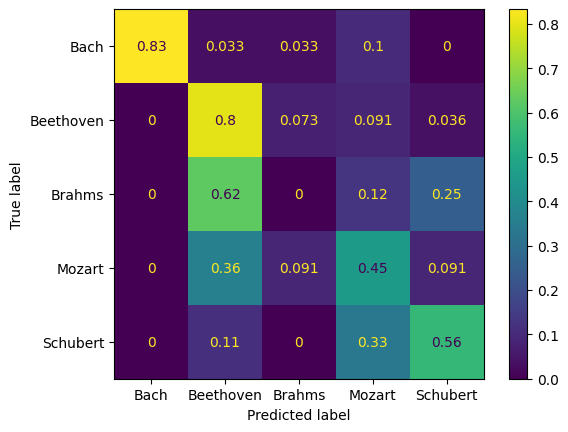

In [26]:
metrics.ConfusionMatrixDisplay.from_predictions(
    all_work_true,
    all_work_pred,
    normalize="true"
)

## Kernelized SVM



### SVM grid search

Za svaku kombinaciju `(C, gamma)` radi se isti 5-fold `StratifiedGroupKFold`, koristi se work-level majority



In [27]:
# 1. Izbor hiperparametara kroz CV.
from sklearn.svm import SVC

svm_model = make_pipeline(
    preprocessing.StandardScaler(),
    SVC(kernel="rbf", class_weight=None),
)
svm_param_grid = {
    "C": [10 ** i for i in range(-1, 3)],
    "gamma": [0.001, 0.005, 0.01, 0.1],
}

results_svm, best_svm = train_classical_model(
    X, y, groups,
    model=svm_model,
    cv=sgkf,
    param_grid=svm_param_grid,
)

svc__C=0.1, svc__gamma=0.001: accuracy=0.5233, macro_f1=0.4844
svc__C=0.1, svc__gamma=0.005: accuracy=0.6463, macro_f1=0.5875
svc__C=0.1, svc__gamma=0.01: accuracy=0.6903, macro_f1=0.6135
svc__C=0.1, svc__gamma=0.1: accuracy=0.0878, macro_f1=0.0318
svc__C=1, svc__gamma=0.001: accuracy=0.7088, macro_f1=0.6248
svc__C=1, svc__gamma=0.005: accuracy=0.7523, macro_f1=0.5584
svc__C=1, svc__gamma=0.01: accuracy=0.7527, macro_f1=0.5183
svc__C=1, svc__gamma=0.1: accuracy=0.4873, macro_f1=0.1310
svc__C=10, svc__gamma=0.001: accuracy=0.7705, macro_f1=0.5964
svc__C=10, svc__gamma=0.005: accuracy=0.7792, macro_f1=0.5514
svc__C=10, svc__gamma=0.01: accuracy=0.7436, macro_f1=0.4577
svc__C=10, svc__gamma=0.1: accuracy=0.4873, macro_f1=0.1310
svc__C=100, svc__gamma=0.001: accuracy=0.7705, macro_f1=0.5876
svc__C=100, svc__gamma=0.005: accuracy=0.7709, macro_f1=0.5468
svc__C=100, svc__gamma=0.01: accuracy=0.7436, macro_f1=0.4577
svc__C=100, svc__gamma=0.1: accuracy=0.4873, macro_f1=0.1310

Best params: {'

In [28]:
print("Izabrani parametri:", best_svm[0])
print("CV accuracy za izbor:", best_svm[1])
print("CV macro F1 za izbor:", best_svm[2])

Izabrani parametri: {'svc__C': 10, 'svc__gamma': 0.001}
CV accuracy za izbor: 0.7705204216073781
CV macro F1 za izbor: 0.5964019980019979


### SVM — završni izvještaj u ovom notebooku

Ova ćelija pravi objedinjeni classification report preko svih validacionih djela.

I ovdje postoji razlika između tuninga i izvještaja: finalna ćelija koristi `C=100`, `gamma=0.001` i
`class_weight="balanced"`, dok je tuning iznad kao najbolju kombinaciju ispisao `C=10`, `gamma=0.001`
i tokom tuninga koristio `sample_weight`.

In [29]:
# 2. Konačna evaluacija kroz nested CV.
fold_results_svm, all_work_true, all_work_pred = nested_cv_classical(
    X, y, groups,
    model=svm_model,
    param_grid=svm_param_grid,
    outer_cv=sgkf_outer,
    inner_cv=sgkf,
)

Fold 1:

svc__C=0.1, svc__gamma=0.001: accuracy=0.5456, macro_f1=0.4819
svc__C=0.1, svc__gamma=0.005: accuracy=0.6858, macro_f1=0.5735
svc__C=0.1, svc__gamma=0.01: accuracy=0.7077, macro_f1=0.5407
svc__C=0.1, svc__gamma=0.1: accuracy=0.1352, macro_f1=0.0420
svc__C=1, svc__gamma=0.001: accuracy=0.7965, macro_f1=0.6816
svc__C=1, svc__gamma=0.005: accuracy=0.8151, macro_f1=0.6129
svc__C=1, svc__gamma=0.01: accuracy=0.7715, macro_f1=0.5651
svc__C=1, svc__gamma=0.1: accuracy=0.4861, macro_f1=0.1306
svc__C=10, svc__gamma=0.001: accuracy=0.8137, macro_f1=0.6281
svc__C=10, svc__gamma=0.005: accuracy=0.7915, macro_f1=0.5989
svc__C=10, svc__gamma=0.01: accuracy=0.7485, macro_f1=0.4938
svc__C=10, svc__gamma=0.1: accuracy=0.4861, macro_f1=0.1306
svc__C=100, svc__gamma=0.001: accuracy=0.8026, macro_f1=0.6059
svc__C=100, svc__gamma=0.005: accuracy=0.7915, macro_f1=0.5989
svc__C=100, svc__gamma=0.01: accuracy=0.7485, macro_f1=0.4938
svc__C=100, svc__gamma=0.1: accuracy=0.4861, macro_f1=0.1306

Best p

In [30]:
print(
    metrics.classification_report(
        all_work_true,
        all_work_pred
    )
)

print(
    "Overall work accuracy:",
    metrics.accuracy_score(
        all_work_true,
        all_work_pred
    )
)

print(
    "Overall work macro F1:",
    metrics.f1_score(
        all_work_true,
        all_work_pred,
        average = "macro"
    )
)

              precision    recall  f1-score   support

        Bach       1.00      0.87      0.93        30
   Beethoven       0.82      0.82      0.82        55
      Brahms       0.29      0.25      0.27         8
      Mozart       0.41      0.64      0.50        11
    Schubert       0.75      0.67      0.71         9

    accuracy                           0.76       113
   macro avg       0.65      0.65      0.64       113
weighted avg       0.78      0.76      0.77       113

Overall work accuracy: 0.7610619469026548
Overall work macro F1: 0.643860453272218


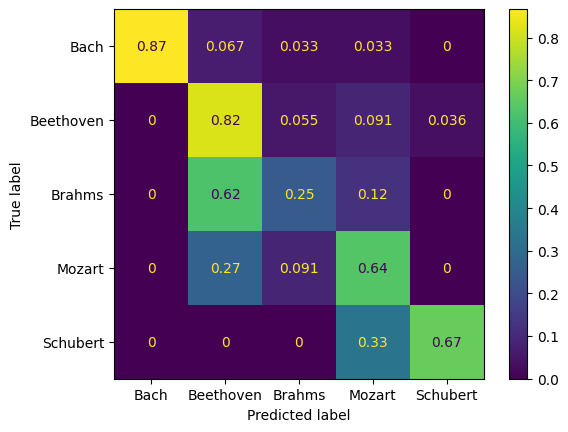

In [31]:
from matplotlib import pyplot as plt

metrics.ConfusionMatrixDisplay.from_predictions(
    all_work_true,
    all_work_pred,
    normalize="true"
)

plt.show()

# KNN

In [32]:
# 1. Izbor hiperparametara kroz CV.
from sklearn.neighbors import KNeighborsClassifier

# Postojeće CV funkcije prosljeđuju sample_weight svakom modelu.
# KNN ga ne podržava, pa ga ovaj adapter prihvata i zadržava običan KNN fit.
class KNNForClassicalCV(KNeighborsClassifier):
    def fit(self, X, y, sample_weight=None):
        return super().fit(X, y)


knn_model = make_pipeline(
    preprocessing.StandardScaler(),
    KNNForClassicalCV(metric="minkowski", p=2),
)
knn_param_grid = {
    "n_neighbors": [3, 5, 7],
    "weights": ["uniform", "distance"],
}

results_knn, best_knn = train_classical_model(
    X, y, groups,
    model=knn_model,
    cv=sgkf,
    param_grid=knn_param_grid,
)

knnforclassicalcv__n_neighbors=3, knnforclassicalcv__weights=uniform: accuracy=0.7168, macro_f1=0.3625
knnforclassicalcv__n_neighbors=3, knnforclassicalcv__weights=distance: accuracy=0.7175, macro_f1=0.3673
knnforclassicalcv__n_neighbors=5, knnforclassicalcv__weights=uniform: accuracy=0.7259, macro_f1=0.3668
knnforclassicalcv__n_neighbors=5, knnforclassicalcv__weights=distance: accuracy=0.7168, macro_f1=0.3623
knnforclassicalcv__n_neighbors=7, knnforclassicalcv__weights=uniform: accuracy=0.7168, macro_f1=0.3612
knnforclassicalcv__n_neighbors=7, knnforclassicalcv__weights=distance: accuracy=0.7168, macro_f1=0.3612

Best params: {'knnforclassicalcv__n_neighbors': 5, 'knnforclassicalcv__weights': 'uniform'}
Best accuracy: 0.7258563899868247
Best macro F1: 0.3667735840149634 



In [33]:
print("Izabrani parametri:", best_knn[0])
print("CV accuracy za izbor:", best_knn[1])
print("CV macro F1 za izbor:", best_knn[2])

Izabrani parametri: {'knnforclassicalcv__n_neighbors': 5, 'knnforclassicalcv__weights': 'uniform'}
CV accuracy za izbor: 0.7258563899868247
CV macro F1 za izbor: 0.3667735840149634


In [34]:
# 2. Konačna evaluacija kroz nested CV.
fold_results_knn, all_work_true, all_work_pred = nested_cv_classical(
    X, y, groups,
    model=knn_model,
    param_grid=knn_param_grid,
    outer_cv=sgkf_outer,
    inner_cv=sgkf,
)

Fold 1:

knnforclassicalcv__n_neighbors=3, knnforclassicalcv__weights=uniform: accuracy=0.7274, macro_f1=0.4180
knnforclassicalcv__n_neighbors=3, knnforclassicalcv__weights=distance: accuracy=0.7051, macro_f1=0.4069
knnforclassicalcv__n_neighbors=5, knnforclassicalcv__weights=uniform: accuracy=0.7485, macro_f1=0.4361
knnforclassicalcv__n_neighbors=5, knnforclassicalcv__weights=distance: accuracy=0.7263, macro_f1=0.4107
knnforclassicalcv__n_neighbors=7, knnforclassicalcv__weights=uniform: accuracy=0.7163, macro_f1=0.4207
knnforclassicalcv__n_neighbors=7, knnforclassicalcv__weights=distance: accuracy=0.7057, macro_f1=0.4185

Best params: {'knnforclassicalcv__n_neighbors': 5, 'knnforclassicalcv__weights': 'uniform'}
Best accuracy: 0.7484795321637426
Best macro F1: 0.4360749105966497 

outer fold: best_params={'knnforclassicalcv__n_neighbors': 5, 'knnforclassicalcv__weights': 'uniform'} -> accuracy=0.6818, macro_f1=0.3357


Fold 2:

knnforclassicalcv__n_neighbors=3, knnforclassicalcv__weig

              precision    recall  f1-score   support

        Bach       1.00      0.87      0.93        30
   Beethoven       0.64      0.98      0.78        55
      Brahms       0.00      0.00      0.00         8
      Mozart       0.50      0.09      0.15        11
    Schubert       0.00      0.00      0.00         9

    accuracy                           0.72       113
   macro avg       0.43      0.39      0.37       113
weighted avg       0.63      0.72      0.64       113

Overall work accuracy: 0.7168141592920354
Overall work macro F1: 0.37187919993675395


/home/david/Desktop/DPJ/PYTHON/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/david/Desktop/DPJ/PYTHON/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/david/Desktop/DPJ/PYTHON/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metri

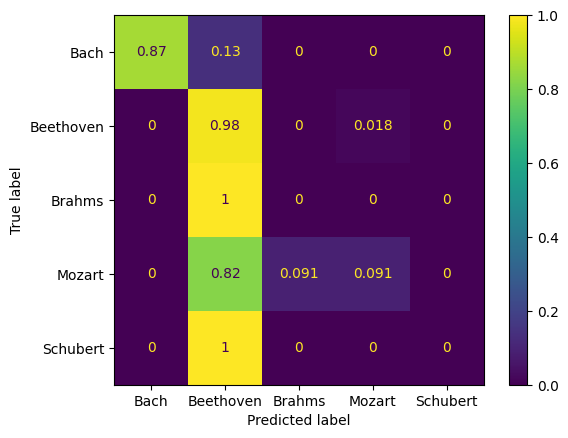

In [35]:
print(metrics.classification_report(all_work_true, all_work_pred))
print("Overall work accuracy:", metrics.accuracy_score(all_work_true, all_work_pred))
print("Overall work macro F1:", metrics.f1_score(all_work_true, all_work_pred, average="macro"))

metrics.ConfusionMatrixDisplay.from_predictions(
    all_work_true, all_work_pred, normalize="true",
)
plt.show()

# Random Forest Classifer

In [ ]:
from sklearn.ensemble import RandomForestClassifier

### Random Forest — tuning

Za svaku kombinaciju hiperparametara koristi se isti group-aware 5-fold postupak i `sample_weight`.


In [37]:
from sklearn.ensemble import RandomForestClassifier

# 1. Izbor hiperparametara kroz CV.
rf_model = RandomForestClassifier(
    max_features="sqrt",
    class_weight=None,
    random_state=42,
    n_jobs=-1,
)
rf_param_grid = {
    "n_estimators": [300, 500],
    "max_depth": [None, 10, 20],
    "min_samples_leaf": [1, 2, 4],
}

results_rf, best_rf = train_classical_model(
    X, y, groups,
    model=rf_model,
    cv=sgkf,
    param_grid=rf_param_grid,
)

n_estimators=300, max_depth=None, min_samples_leaf=1: accuracy=0.7785, macro_f1=0.5613
n_estimators=300, max_depth=None, min_samples_leaf=2: accuracy=0.7963, macro_f1=0.6040
n_estimators=300, max_depth=None, min_samples_leaf=4: accuracy=0.7959, macro_f1=0.6307
n_estimators=300, max_depth=10, min_samples_leaf=1: accuracy=0.7694, macro_f1=0.5957
n_estimators=300, max_depth=10, min_samples_leaf=2: accuracy=0.7785, macro_f1=0.5967
n_estimators=300, max_depth=10, min_samples_leaf=4: accuracy=0.7781, macro_f1=0.6244
n_estimators=300, max_depth=20, min_samples_leaf=1: accuracy=0.7785, macro_f1=0.5613
n_estimators=300, max_depth=20, min_samples_leaf=2: accuracy=0.7963, macro_f1=0.6040
n_estimators=300, max_depth=20, min_samples_leaf=4: accuracy=0.7959, macro_f1=0.6307
n_estimators=500, max_depth=None, min_samples_leaf=1: accuracy=0.7694, macro_f1=0.5493
n_estimators=500, max_depth=None, min_samples_leaf=2: accuracy=0.7963, macro_f1=0.6040
n_estimators=500, max_depth=None, min_samples_leaf=4: a

### Random Forest — objedinjena evaluacija

In [38]:
# 2. Konačna evaluacija kroz nested CV.
fold_results_rf, all_work_true, all_work_pred = nested_cv_classical(
    X, y, groups,
    model=rf_model,
    param_grid=rf_param_grid,
    outer_cv=sgkf_outer,
    inner_cv=sgkf,
)

Fold 1:

n_estimators=300, max_depth=None, min_samples_leaf=1: accuracy=0.8031, macro_f1=0.6195
n_estimators=300, max_depth=None, min_samples_leaf=2: accuracy=0.8031, macro_f1=0.6065
n_estimators=300, max_depth=None, min_samples_leaf=4: accuracy=0.8262, macro_f1=0.6633
n_estimators=300, max_depth=10, min_samples_leaf=1: accuracy=0.8156, macro_f1=0.6459
n_estimators=300, max_depth=10, min_samples_leaf=2: accuracy=0.7945, macro_f1=0.6206
n_estimators=300, max_depth=10, min_samples_leaf=4: accuracy=0.8051, macro_f1=0.6318
n_estimators=300, max_depth=20, min_samples_leaf=1: accuracy=0.8031, macro_f1=0.6195
n_estimators=300, max_depth=20, min_samples_leaf=2: accuracy=0.8031, macro_f1=0.6065
n_estimators=300, max_depth=20, min_samples_leaf=4: accuracy=0.8262, macro_f1=0.6633
n_estimators=500, max_depth=None, min_samples_leaf=1: accuracy=0.8143, macro_f1=0.6220
n_estimators=500, max_depth=None, min_samples_leaf=2: accuracy=0.8031, macro_f1=0.6065
n_estimators=500, max_depth=None, min_samples_

In [39]:
print(
    metrics.classification_report(
        all_work_true,
        all_work_pred
    )
)

              precision    recall  f1-score   support

        Bach       1.00      0.90      0.95        30
   Beethoven       0.81      0.85      0.83        55
      Brahms       0.50      0.50      0.50         8
      Mozart       0.46      0.55      0.50        11
    Schubert       0.71      0.56      0.62         9

    accuracy                           0.79       113
   macro avg       0.70      0.67      0.68       113
weighted avg       0.80      0.79      0.79       113



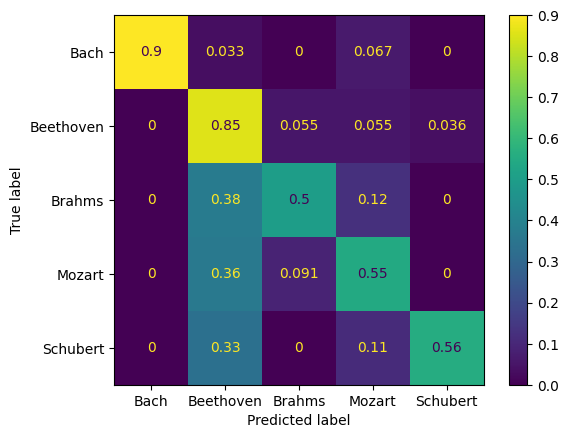

In [40]:
metrics.ConfusionMatrixDisplay.from_predictions(
    all_work_true,
    all_work_pred,
    normalize="true"
)

plt.show()

### Feature importance (Random Forest)

Pošto sad imamo 147 atributa na svega ~113 djela, korisno je provjeriti koje atribute model stvarno
koristi prije nego što se doda još njih (ili prije nego posumnjamo da neki dodati atribut kvari rezultat))

In [ ]:
# nested_cv_classical vraća parametre i predikcije, ali ne čuva trenirane modele.
# Ponovljeni fit na istim spoljašnjim trening foldovima služi samo grafiku važnosti.
all_importances = []
for (train_idx, _), (fold_params, _, _) in zip(
    sgkf_outer.split(X, y, groups), fold_results_rf
):
    importance_model = clone(rf_model).set_params(**fold_params)
    importance_model.fit(
        X[train_idx], y[train_idx],
        sample_weight=make_sample_weights(y[train_idx], groups[train_idx]),
    )
    all_importances.append(importance_model.feature_importances_)

from src.features.feature_engineering import feature_names

names = feature_names()

mean_importance = np.mean(all_importances, axis=0)

order = np.argsort(mean_importance)[::-1]

top_n = 25

top_idx = order[:top_n]

plt.figure(figsize=(8, 10))
plt.barh(
    [names[i] for i in top_idx][::-1],
    mean_importance[top_idx][::-1]
)
plt.xlabel("Mean feature importance (5-fold RF)")
plt.title(f"Top {top_n} atributa po Random Forest importance-u")
plt.tight_layout()
plt.show()

In [ ]:
def feature_group(name):
    if name.startswith("mfcc") and "delta" in name:
        return "mfcc_delta"
    if name.startswith("mfcc"):
        return "mfcc"
    if name.startswith("chroma"):
        return "chroma"
    if name.startswith("tonnetz"):
        return "tonnetz"
    if name.startswith("contrast"):
        return "spectral_contrast"
    if name.startswith("flatness"):
        return "spectral_flatness"
    if name.startswith("zcr"):
        return "zero_crossing_rate"
    if name.startswith("rms"):
        return "rms"
    if name in ("tempo", "onset_mean", "onset_std"):
        return "tempo_onset"
    if name in ("harmonic_ratio", "percussive_rms"):
        return "harmonic_percussive"
    return "centroid_bandwidth_rolloff"


groups_importance = {}

for name, importance in zip(names, mean_importance):
    group = feature_group(name)
    groups_importance[group] = groups_importance.get(group, 0.0) + importance

group_order = sorted(
    groups_importance.items(),
    key=lambda item: item[1],
    reverse=True
)

plt.figure(figsize=(8, 5))
plt.barh(
    [g for g, _ in group_order][::-1],
    [v for _, v in group_order][::-1]
)
plt.xlabel("Zbir mean feature importance po grupi")
plt.title("Doprinos po grupi atributa (RF, 5-fold)")
plt.tight_layout()
plt.show()

---

## XGBoost

Gradient boosting ansambl — stabla se dodaju sekvencijalno, svako ispravlja greške prethodnih. Često
nadmaši Random Forest na ovakvim tabelarnim feature setovima. `LabelEncoder` je potreban jer XGBoost
očekuje numeričke labele, ne stringove.

In [ ]:
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
le.fit(y)

all_work_true = []
all_work_pred = []

for train_idx, val_idx in sgkf.split(X, y, groups):
    X_train_fold = X[train_idx]
    y_train_fold = le.transform(y[train_idx])
    groups_train = groups[train_idx]

    X_val_fold = X[val_idx]
    y_val_fold = y[val_idx]
    groups_val = groups[val_idx]

    sample_weights = make_sample_weights(y[train_idx], groups_train)

    model = XGBClassifier(
        n_estimators=300,
        max_depth=5,
        learning_rate=0.1,
        eval_metric="mlogloss",
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train_fold, y_train_fold, sample_weight=sample_weights)

    pred = le.inverse_transform(model.predict(X_val_fold))

    work_true, work_pred = majority_vote_prediction(y_val_fold, pred, groups_val)

    all_work_true.extend(work_true)
    all_work_pred.extend(work_pred)

print(metrics.classification_report(all_work_true, all_work_pred))